# kMeans
Reading
* Leskovec: 7.3
* Brunton: 5.3

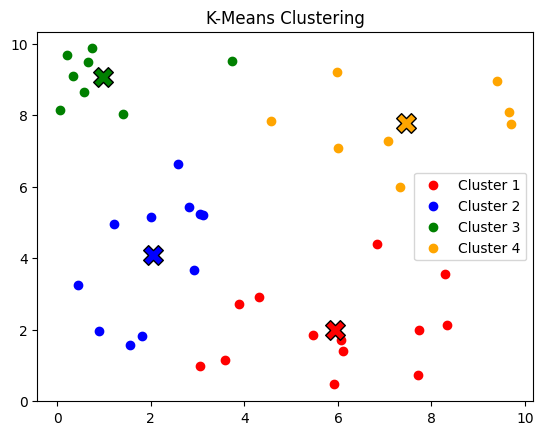

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 40 random points
np.random.seed(42)
points = np.random.rand(40, 2) * 10

# 1. Number of centroids
k = 4

# 2. Randomly place the centroids throughout the data
centroids = points[np.random.choice(40, k, replace=False)]

# 3. Measure the distance from every point to each centroid and assign each point to the nearest centroid
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def assign_clusters(points, centroids):
    clusters = []
    for point in points:
        distances = [euclidean_distance(point, c) for c in centroids]
        clusters.append(np.argmin(distances))
    return np.array(clusters)

# 4. Find the center of your clusters and move the centroids to those centers
def update_centroids(points, clusters, k):
    new_centroids = []
    for i in range(k):
        cluster_points = points[clusters == i]
        new_centroids.append(cluster_points.mean(axis=0))
    return np.array(new_centroids)

# 5. Repeat steps 3-4 until points stop changing clusters
for _ in range(100):
    clusters = assign_clusters(points, centroids)
    new_centroids = update_centroids(points, clusters, k)
    if np.allclose(centroids, new_centroids):
        break
    centroids = new_centroids

# Plot
colors = ['red', 'blue', 'green', 'orange']
for i in range(k):
    cluster_points = points[clusters == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[i], label=f'Cluster {i+1}')
    plt.scatter(centroids[i, 0], centroids[i, 1], color=colors[i], marker='X', s=200, edgecolors='black')

plt.title('K-Means Clustering')
plt.legend()
plt.savefig('kmeans_plot.png', dpi=150, bbox_inches='tight')
plt.show()

-----

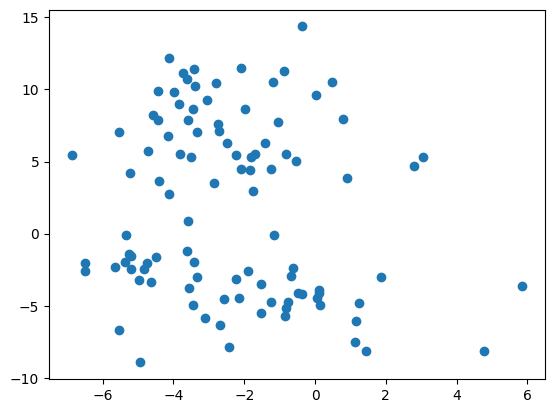

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=100, n_features=2, centers=4,
                  cluster_std=1.8,random_state=50)

plt.scatter(X[:,0], X[:,1])

## kMeans

[0 0 0 1 2 2 3 1 0 1 2 0 1 3 2 3 3 3 1 1 0 2 2 0 3 3 0 2 2 1 1 0 2 3 0 2 1
 1 0 0 2 2 2 0 1 3 0 2 2 1 1 2 3 3 1 1 0 3 0 0 1 1 3 2 0 1 1 1 1 1 1 2 1 0
 0 3 1 2 1 2 0 0 3 1 3 3 1 0 2 2 1 2 2 2 1 0 1 2 3 3]
[0 0 1 0 2]


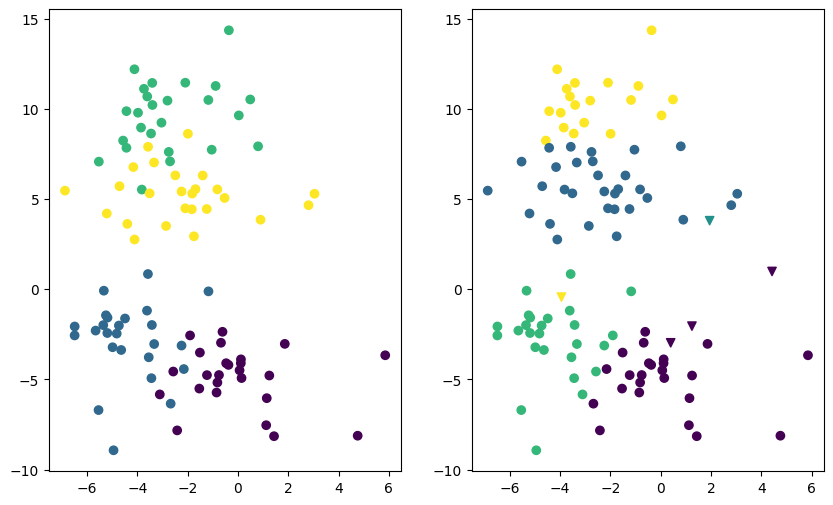

In [3]:
from sklearn.cluster import KMeans

k=4
kmeans = KMeans(n_clusters=k, random_state=30, n_init='auto')
kmeans.fit(X)

# Results
print(kmeans.labels_)

# Prediction
X_test = np.random.rand(5,2)*10 - 5
y_test = kmeans.predict(X_test)
print(y_test)

fig,ax = plt.subplots(1,2, figsize=(10,6))
ax[0].scatter(X[:,0], X[:,1], c=y)
ax[1].scatter(X[:,0], X[:,1], c=kmeans.labels_)
ax[1].scatter(X_test[:,0], X_test[:,1], c=y_test, marker='v')

In [4]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y, kmeans.labels_)

array([[22,  0,  3,  0],
       [ 2,  0, 23,  0],
       [ 0,  7,  0, 18],
       [ 0, 24,  0,  1]])

array([[22,  3,  0,  0],
       [ 2, 23,  0,  0],
       [ 0,  0, 18,  7],
       [ 0,  0,  1, 24]])

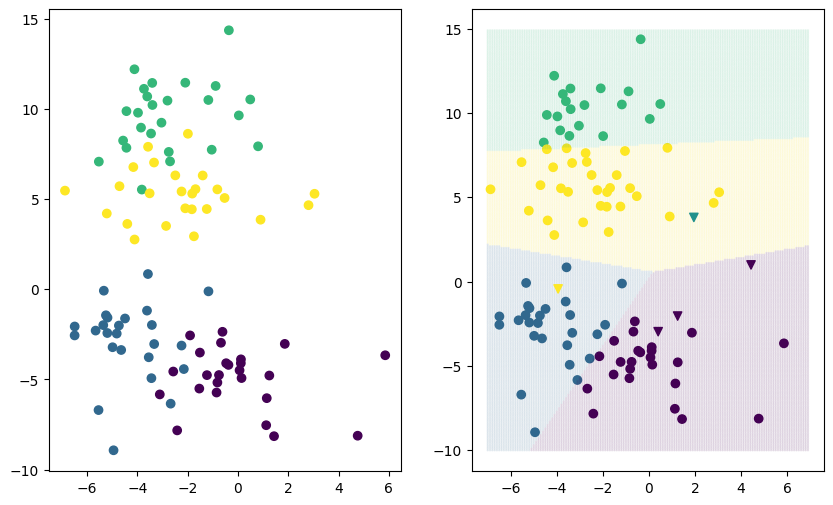

In [5]:
# Relabel
relabel = np.choose(kmeans.labels_,[0,3,1,2])
#y_pred = np.choose(y_test)

# Results Map
grid_x, grid_y = np.meshgrid(np.arange(-7, 7, 0.1), np.arange(-10, 15, 0.1))
grid_pts = np.array([grid_x.flatten(),grid_y.flatten()]).T
grid_grp = kmeans.predict(grid_pts)
grid_grp = np.choose(grid_grp, [0,3,1,2])

fig,ax = plt.subplots(1,2, figsize=(10,6))
ax[0].scatter(X[:,0], X[:,1], c=y)
ax[1].scatter(X[:,0], X[:,1], c=relabel)
ax[1].scatter(grid_pts[:,0], grid_pts[:,1], c=grid_grp, alpha=0.1, marker='.', s=2)
ax[1].scatter(X_test[:,0], X_test[:,1], c=y_test, marker='v')

confusion_matrix(y, relabel)

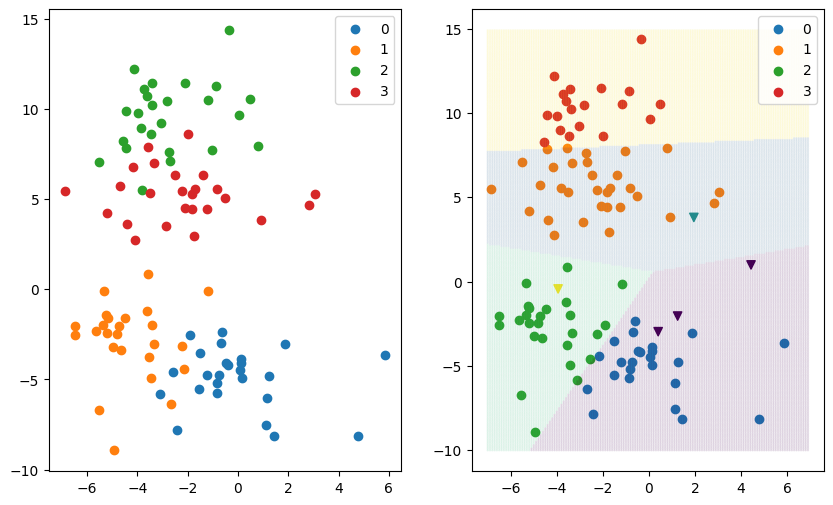

In [6]:
### Another way to relabel groups

# Plot it
fig,ax = plt.subplots(1,2, figsize=(10,6))
for grp in range(k):
    ax[0].scatter(X[y==grp,0], X[y==grp,1], label=grp)
    ax[1].scatter(X[kmeans.labels_==grp,0], X[kmeans.labels_==grp,1], label=grp)

# Results Map
grid_x, grid_y = np.meshgrid(np.arange(-7, 7, 0.1), np.arange(-10, 15, 0.1))
grid_pts = np.array([grid_x.flatten(),grid_y.flatten()]).T
grid_grp = kmeans.predict(grid_pts)

# Plot
ax[0].legend()
ax[1].scatter(X_test[:,0], X_test[:,1], c=y_test, marker='v')
ax[1].scatter(grid_pts[:,0], grid_pts[:,1], c=grid_grp, alpha=0.1, marker=".", s=2)
ax[1].legend()